In [ ]:
# Phase 2 — EDA After Preprocessing

import os
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
from nltk.util import ngrams
import arabic_reshaper
from bidi.algorithm import get_display


processed_csv = "../data/processed/merged_processed.csv"
figures_path = "../reports/figures"

os.makedirs(figures_path, exist_ok=True)


df = pd.read_csv(processed_csv)
df["text_processed"] = df["text_processed"].astype(str)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (41940, 3)


,text,label,text_processed
0,كثيرا ما ارتبطت المصادر التاريخية في الأندلس خ...,0,ربط صدر ارخ دلس كتب رجم هرس رمج وغر درس حية عل...
1,يعد العامل الثقافي احد ابرز الاسباب التي يعزى ...,0,يعد عمل ثقف احد برز سبب يعز سقط دول وحد ، حتي ...
2,شكلت تلك الجهود والمساعي الرائدة التي قام بها ...,0,شكل جهد سعي رءد قدة ثور خلل رحل اول بحث صدر مو...
3,يقوم المقال على اشكالية الضرائب الغير شرعية في...,0,يقم قال علي شكل ضرءب غير شرع خلف رحل دول ربط و...
4,تتفق المصادر التاريخية المتوفرة حول موضوع تطور...,0,تفق صدر ارخ توفر حول وضع تطر حرك وطن جزءر نهي ...


In [ ]:
# Statistical Features

df["word_count"] = df["text_processed"].apply(lambda x: len(x.split()))
df["char_count"] = df["text_processed"].apply(len)
df["avg_word_len"] = df["char_count"] / df["word_count"]
df["sentence_count"] = df["text_processed"].apply(lambda x: max(x.count("،") + x.count(".") + 1, 1))
df["avg_sentence_len"] = df["word_count"] / df["sentence_count"]

def type_token_ratio(text):
    words = text.split()
    return len(set(words)) / len(words) if len(words) else 0

df["ttr"] = df["text_processed"].apply(type_token_ratio)

stats = df.groupby("label")[["word_count","char_count","avg_word_len",
                             "sentence_count","avg_sentence_len","ttr"]].mean()
stats.index = ["Human", "AI"]

print("=== Statistical Analysis ===")
stats.round(2)


=== Statistical Analysis ===


,word_count,char_count,avg_word_len,sentence_count,avg_sentence_len,ttr
Human,97.81,417.95,4.28,7.84,17.28,0.74
AI,86.11,366.83,4.26,5.84,18.00,0.71


 2) WordCloud + Top N-grams

In [ ]:
#Arabic reshaping helpers
def reshape_ar(text):
    return get_display(arabic_reshaper.reshape(text))

In [ ]:
#Generate WordCloud
def generate_wordcloud(text_series):
    text = " ".join(text_series)
    wc = WordCloud(width=400, height=300, background_color="white",
                   font_path="C:/Windows/Fonts/arial.ttf")
    return wc.generate(reshape_ar(text))

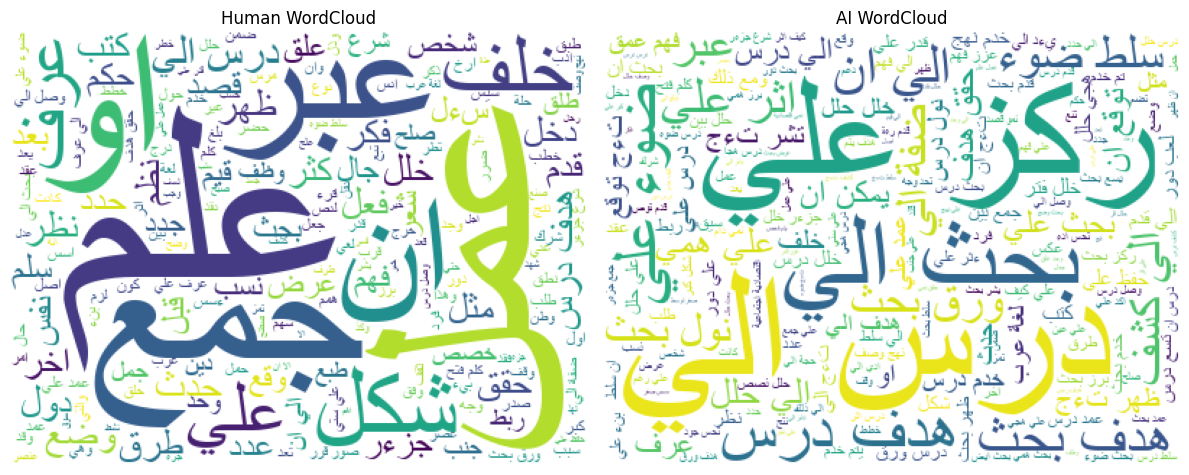

In [ ]:
#Create wordclouds
human_wc = generate_wordcloud(df[df["label"]==0]["text_processed"])
ai_wc = generate_wordcloud(df[df["label"]==1]["text_processed"])

# Plot
fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].imshow(human_wc); ax[0].axis("off"); ax[0].set_title("Human WordCloud")
ax[1].imshow(ai_wc);    ax[1].axis("off"); ax[1].set_title("AI WordCloud")

plt.tight_layout()
plt.savefig(f"{figures_path}/EDA_wordclouds.png", dpi=300)
plt.show()

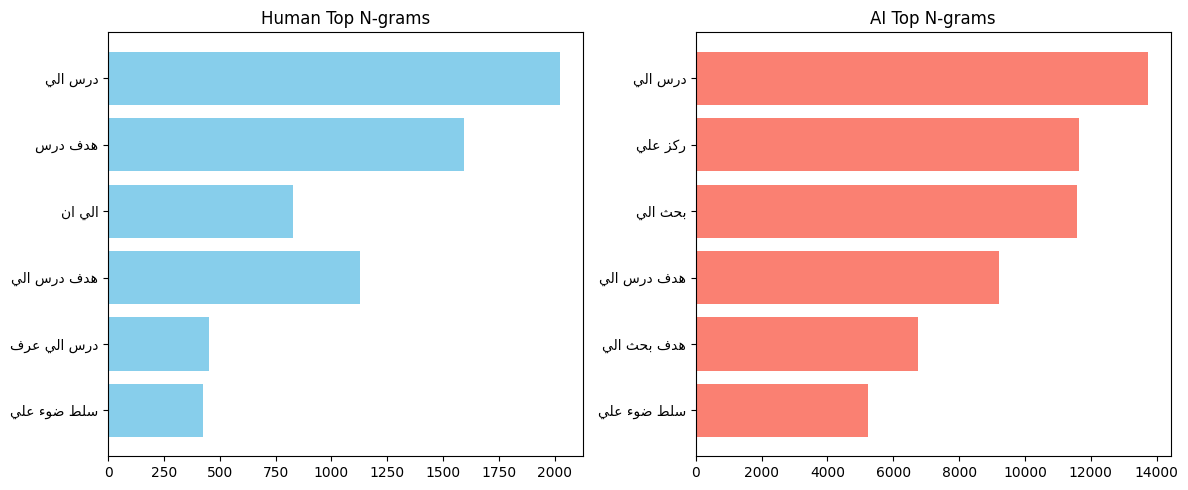

In [ ]:
#Top Bigrams / Trigrams
def get_top_ngrams(text_series, top_n=3, n=2):
    all_ngr = []
    for t in text_series:
        tokens = t.split()
        all_ngr.extend(list(ngrams(tokens, n)))
    freq = Counter(all_ngr).most_common(top_n)
    labels = [reshape_ar(" ".join(x)) for x,_ in freq]
    counts = [c for _,c in freq]
    return labels, counts

# Human
h2_lbl, h2_cnt = get_top_ngrams(df[df.label==0]["text_processed"], n=2)
h3_lbl, h3_cnt = get_top_ngrams(df[df.label==0]["text_processed"], n=3)

# AI
a2_lbl, a2_cnt = get_top_ngrams(df[df.label==1]["text_processed"], n=2)
a3_lbl, a3_cnt = get_top_ngrams(df[df.label==1]["text_processed"], n=3)

# Plot
fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].barh(h2_lbl + h3_lbl, h2_cnt + h3_cnt, color="skyblue")
ax[0].invert_yaxis(); ax[0].set_title("Human Top N-grams")

ax[1].barh(a2_lbl + a3_lbl, a2_cnt + a3_cnt, color="salmon")
ax[1].invert_yaxis(); ax[1].set_title("AI Top N-grams")

plt.tight_layout()
plt.savefig(f"{figures_path}/EDA_top_ngrams.png", dpi=300)
plt.show()



=== Lexical Analysis ===
Human    105547
AI       379359
Name: function_words_count, dtype: int64


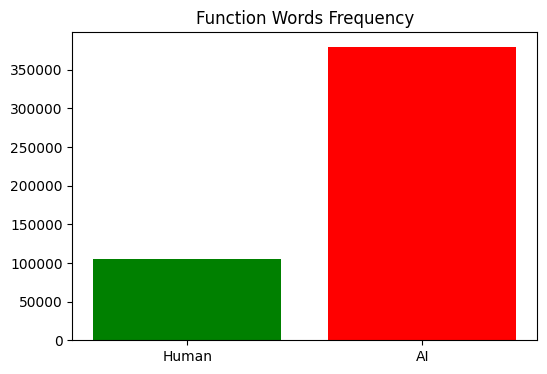

In [ ]:
#3) Lexical Analysis ---> Function Words
function_words = ["في","من","على","عن","إلى","ما","لا","كل"]

df["function_words_count"] = df["text"].apply(
    lambda x: sum(x.split().count(w) for w in function_words)
)

lexical = df.groupby("label")["function_words_count"].sum()
lexical.index = ["Human","AI"]

print("\n=== Lexical Analysis ===")
print(lexical)

plt.figure(figsize=(6,4))
plt.bar(lexical.index, lexical.values, color=["green","red"])
plt.title("Function Words Frequency")
plt.savefig(f"{figures_path}/EDA_function_words.png", dpi=300)
plt.show()

In [ ]:
# Punctuation Analysis
punctuation = ["،",".","!","؟",":",";"]

for p in punctuation:
    df[f"punct_{p}"] = df["text"].apply(lambda x: x.count(p))

punct_stats = df.groupby("label")[[f"punct_{p}" for p in punctuation]].sum()
punct_stats.index = ["Human","AI"]

print("\nPunctuation Stats:\n", punct_stats)


Punctuation Stats:
        punct_،  punct_.  punct_!  punct_؟  punct_:  punct_;
Human    57360    26848        6      720     3506       34
AI      162392   161638        0      423     5225       24


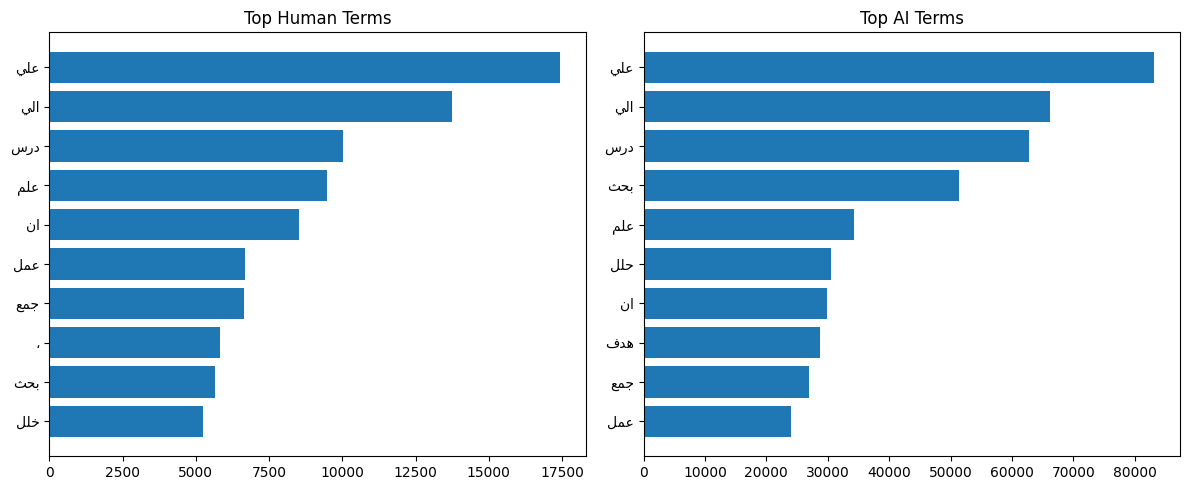

In [ ]:
#Specific Frequent Words (Top Terms)
def top_terms(series, n=10):
    words = []
    for t in series:
        words.extend(t.split())
    freq = Counter(words).most_common(n)
    labels = [reshape_ar(w) for w,_ in freq]
    counts = [c for _,c in freq]
    return labels, counts

h_lbl, h_cnt = top_terms(df[df.label==0]["text_processed"])
a_lbl, a_cnt = top_terms(df[df.label==1]["text_processed"])

fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].barh(h_lbl, h_cnt); ax[0].invert_yaxis(); ax[0].set_title("Top Human Terms")
ax[1].barh(a_lbl, a_cnt); ax[1].invert_yaxis(); ax[1].set_title("Top AI Terms")

plt.tight_layout()
plt.savefig(f"{figures_path}/EDA_specific_terms.png", dpi=300)
plt.show()

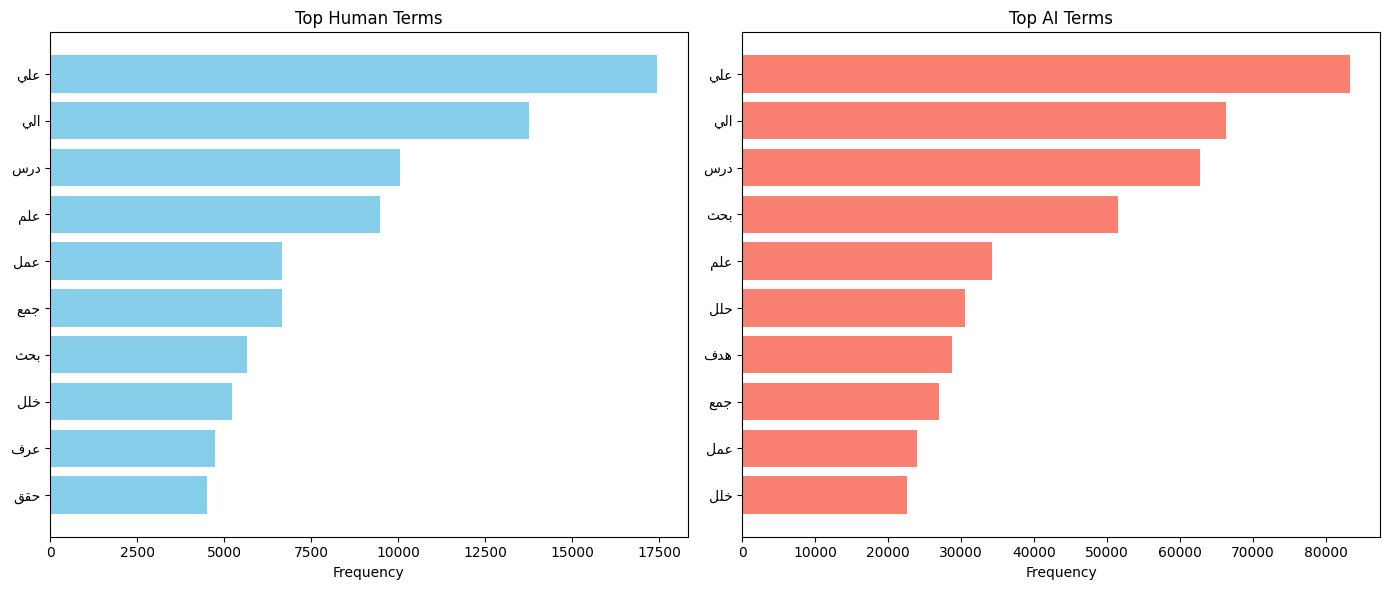

Top Human Terms: ['علي', 'الي', 'درس', 'علم', 'ان', 'عمل', 'جمع', '،', 'بحث', 'خلل']
Top AI Terms: ['علي', 'الي', 'درس', 'بحث', 'علم', 'حلل', 'ان', 'هدف', 'جمع', 'عمل']


In [ ]:
# Specific Frequent Words (Top Terms) 

import re
from collections import Counter
import matplotlib.pyplot as plt

import arabic_reshaper
from bidi.algorithm import get_display

def reshape_arabic(text):
    """Fix Arabic display for matplotlib."""
    try:
        reshaped = arabic_reshaper.reshape(text)
        return get_display(reshaped)
    except:
        return text


# Arabic letters range 
arabic_pattern = re.compile(r"^[\u0600-\u06FF]+$")

def clean_and_filter_words(word_list, min_len=3):
    """
    Removes non-Arabic tokens, strange characters, 
    and filters short words (default < 3 chars).
    """
    cleaned = []
    for w in word_list:
        w = w.strip()

        
        if w == "":
            continue
        
        if not arabic_pattern.match(w):
            continue
        
        
        if len(w) < min_len:
            continue
        
        cleaned.append(w)

    return cleaned


def get_top_terms(text_series, n=10):
    """Extracts top frequent Arabic terms after cleaning."""
    all_words = []

    for text in text_series:
        words = str(text).split()
        clean_words = clean_and_filter_words(words)
        all_words.extend(clean_words)

    freq_dist = Counter(all_words)
    top = freq_dist.most_common(n)

    
    labels = [reshape_arabic(w) for w, _ in top]
    counts = [cnt for _, cnt in top]

    return labels, counts


# Top Human Terms
human_terms_labels, human_terms_counts = get_top_terms(
    df[df['label'] == 0]['text_processed'], 
    n=10
)

#  Top AI Terms
ai_terms_labels, ai_terms_counts = get_top_terms(
    df[df['label'] == 1]['text_processed'], 
    n=10
)


#  Plot Top Terms (Human vs AI)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Human plot
axes[0].barh(human_terms_labels, human_terms_counts, color='skyblue')
axes[0].invert_yaxis()
axes[0].set_title("Top Human Terms")
axes[0].set_xlabel("Frequency")

# AI plot
axes[1].barh(ai_terms_labels, ai_terms_counts, color='salmon')
axes[1].invert_yaxis()
axes[1].set_title("Top AI Terms")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.savefig(f"{figures_path}/EDA_specific_terms_cleaned.png", dpi=300)
plt.show()

print("Top Human Terms:", [w for w, _ in Counter(" ".join(df[df['label']==0]['text_processed']).split()).most_common(10)])
print("Top AI Terms:",    [w for w, _ in Counter(" ".join(df[df['label']==1]['text_processed']).split()).most_common(10)])



# =========================================================
# Compact EDA after Preprocessing: Stats, WordClouds, Top 3-grams, Lexical Analysis - اخر نسخة - مدموجة فقط
# =========================================================

=== Statistical Analysis (After Preprocessing) ===
       word_count  char_count  avg_word_len  sentence_count  avg_sentence_len  \
Human       97.81      417.95          4.28             1.0             97.81   
AI          86.11      366.83          4.26             1.0             86.11   

        ttr  
Human  0.74  
AI     0.71  


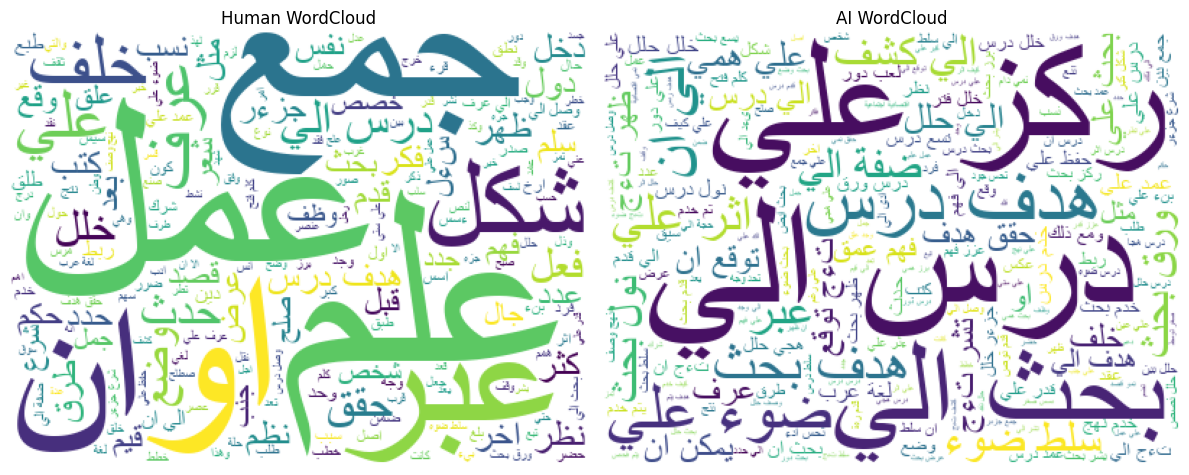

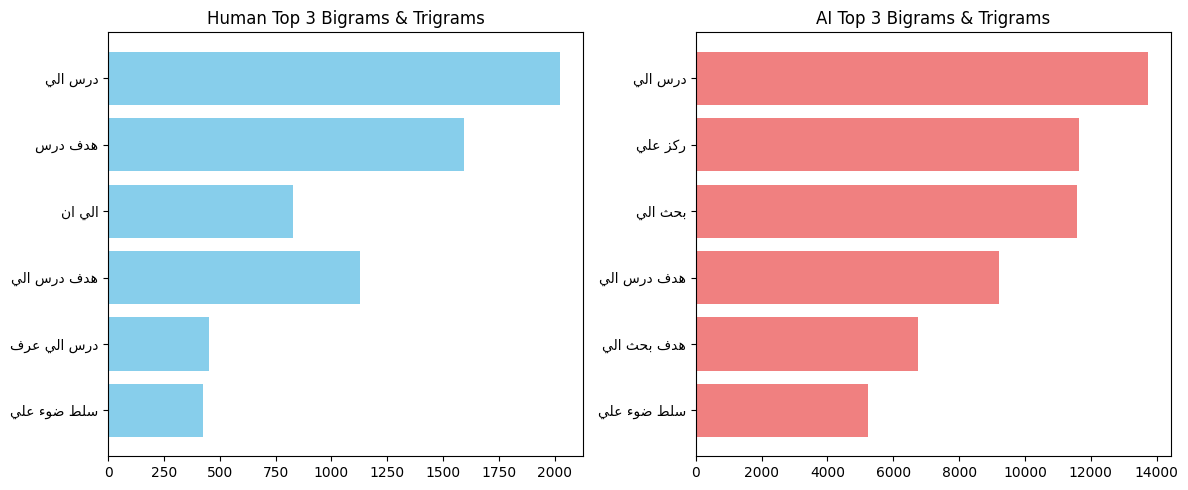


=== Lexical Analysis ===
Function Words Count per Class:
 Human    105547
AI       379359
Name: function_words_count, dtype: int64


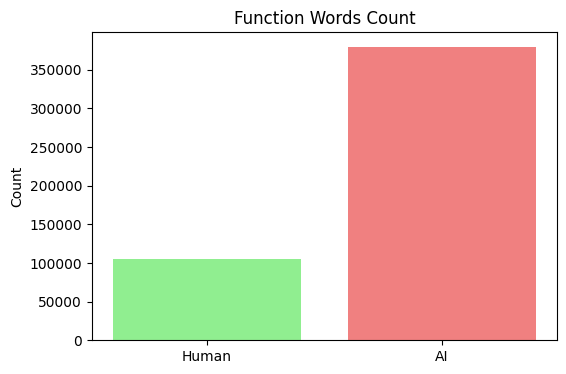


Punctuation Count per Class:
        punct_.  punct_،  punct_!  punct_؟  punct_:  punct_;
Human    26848    57360        6      720     3506       34
AI      161638   162392        0      423     5225       24
Top Human Terms: ['علي', 'الي', 'درس', 'علم', 'ان', 'عمل', 'جمع', '،', 'بحث', 'خلل']
Top AI Terms: ['علي', 'الي', 'درس', 'بحث', 'علم', 'حلل', 'ان', 'هدف', 'جمع', 'عمل']


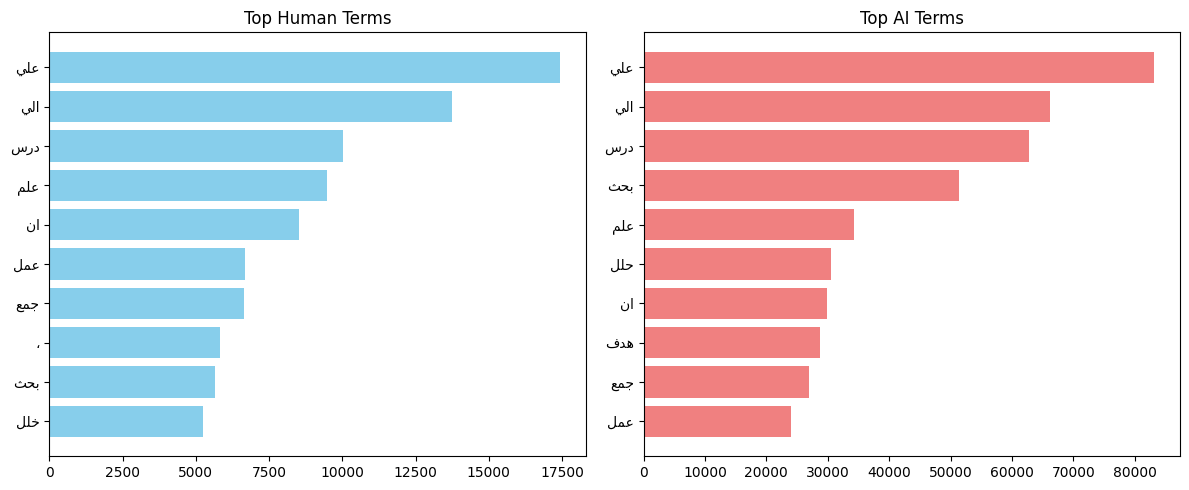

In [ ]:
# =========================================================
# Compact EDA after Preprocessing: Stats, WordClouds, Top 3-grams, Lexical Analysis - اخر نسخة 
# =========================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
from nltk.util import ngrams
import arabic_reshaper
from bidi.algorithm import get_display

# ------------------------
# Paths
# ------------------------
processed_csv = "../data/processed/merged_processed.csv"
figures_path = "../reports/figures"
os.makedirs(figures_path, exist_ok=True)

# ------------------------
# Load data
# ------------------------
df = pd.read_csv(processed_csv)
df['text_processed'] = df['text_processed'].astype(str)

# ------------------------
# 1️ Statistical Analysis (Text Table) - using processed text
# ------------------------
df['word_count'] = df['text_processed'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['text_processed'].apply(lambda x: len(str(x)))
df['avg_word_len'] = df['char_count'] / df['word_count']
df['sentence_count'] = df['text_processed'].apply(lambda x: max(str(x).count('.') + 1, 1))
df['avg_sentence_len'] = df['word_count'] / df['sentence_count']

def type_token_ratio(text):
    words = str(text).split()
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

df['ttr'] = df['text_processed'].apply(type_token_ratio)

eda_stats = df.groupby('label')[['word_count','char_count','avg_word_len',
                                 'sentence_count','avg_sentence_len','ttr']].mean()
eda_stats.index = ['Human','AI']

print("=== Statistical Analysis (After Preprocessing) ===")
print(eda_stats.round(2))

# ------------------------
#  Visualization: WordClouds + Top 3 Bigrams/Trigrams
# ------------------------
def reshape_arabic(text):
    reshaped_text = arabic_reshaper.reshape(text)
    return get_display(reshaped_text)

def generate_wordcloud(text_series):
    text = " ".join(text_series)
    return WordCloud(width=400, height=300, background_color='white',
                     font_path='C:/Windows/Fonts/arial.ttf').generate(reshape_arabic(text))

def get_top_ngrams(text_series, n=3, ngram_range=2):
    all_ngrams = []
    for text in text_series:
        tokens = str(text).split()
        all_ngrams.extend(list(ngrams(tokens, ngram_range)))
    freq_dist = Counter(all_ngrams)
    top = freq_dist.most_common(n)
    labels = [" ".join(t) for t,_ in top]
    labels = [reshape_arabic(lbl) for lbl in labels]
    counts = [cnt for _,cnt in top]
    return labels, counts

# WordClouds
human_wc = generate_wordcloud(df[df['label']==0]['text_processed'])
ai_wc = generate_wordcloud(df[df['label']==1]['text_processed'])

# Top Bigrams + Trigrams
human_bigram_labels, human_bigram_counts = get_top_ngrams(df[df['label']==0]['text_processed'], n=3, ngram_range=2)
ai_bigram_labels, ai_bigram_counts = get_top_ngrams(df[df['label']==1]['text_processed'], n=3, ngram_range=2)

human_trigram_labels, human_trigram_counts = get_top_ngrams(df[df['label']==0]['text_processed'], n=3, ngram_range=3)
ai_trigram_labels, ai_trigram_counts = get_top_ngrams(df[df['label']==1]['text_processed'], n=3, ngram_range=3)

# Plot WordClouds
fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].imshow(human_wc); axes[0].axis('off'); axes[0].set_title("Human WordCloud")
axes[1].imshow(ai_wc); axes[1].axis('off'); axes[1].set_title("AI WordCloud")
plt.tight_layout()
plt.savefig(f"{figures_path}/EDA_wordclouds.png", dpi=300)
plt.show()

# Plot Top N-grams separately for Human and AI
fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].barh(human_bigram_labels + human_trigram_labels, human_bigram_counts + human_trigram_counts, color='skyblue')
axes[0].invert_yaxis(); axes[0].set_title("Human Top 3 Bigrams & Trigrams")
axes[1].barh(ai_bigram_labels + ai_trigram_labels, ai_bigram_counts + ai_trigram_counts, color='lightcoral')
axes[1].invert_yaxis(); axes[1].set_title("AI Top 3 Bigrams & Trigrams")
plt.tight_layout()
plt.savefig(f"{figures_path}/EDA_top_ngrams.png", dpi=300)
plt.show()


#  Lexical Analysis
# Function Words (Plot)
function_words = ['في','من','على','عن','إلى','ما','لا','كل']
df['function_words_count'] = df['text'].apply(lambda x: sum(str(x).split().count(w) for w in function_words))
lexical_stats = df.groupby('label')['function_words_count'].sum()
lexical_stats.index = ['Human','AI']

print("\n=== Lexical Analysis ===")
print("Function Words Count per Class:\n", lexical_stats)

plt.figure(figsize=(6,4))
plt.bar(lexical_stats.index, lexical_stats.values, color=['lightgreen','lightcoral'])
plt.title("Function Words Count")
plt.ylabel("Count")
plt.savefig(f"{figures_path}/EDA_function_words.png", dpi=300)
plt.show()

# Punctuation Analysis (Text Only)
punctuation = ['.','،','!','؟',':',';']
for p in punctuation:
    df[f'punct_{p}'] = df['text'].apply(lambda x: str(x).count(p))
punct_stats = df.groupby('label')[[f'punct_{p}' for p in punctuation]].sum()
punct_stats.index = ['Human','AI']
print("\nPunctuation Count per Class:\n", punct_stats)

# Specific Terms (Top Words) - Text + Plot
def get_top_terms(text_series, n=10):
    all_words = []
    for text in text_series:
        all_words.extend(str(text).split())
    freq_dist = Counter(all_words)
    top = freq_dist.most_common(n)
    labels = [reshape_arabic(w) for w,_ in top]
    counts = [cnt for _,cnt in top]
    return labels, counts

# Human Specific Terms
human_terms_labels, human_terms_counts = get_top_terms(df[df['label']==0]['text_processed'])
ai_terms_labels, ai_terms_counts = get_top_terms(df[df['label']==1]['text_processed'])

print("Top Human Terms:", [w for w, _ in Counter(" ".join(df[df['label']==0]['text_processed']).split()).most_common(10)])
print("Top AI Terms:",    [w for w, _ in Counter(" ".join(df[df['label']==1]['text_processed']).split()).most_common(10)])

# Plot Specific Terms
fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].barh(human_terms_labels, human_terms_counts, color='skyblue'); axes[0].invert_yaxis(); axes[0].set_title("Top Human Terms")
axes[1].barh(ai_terms_labels, ai_terms_counts, color='lightcoral'); axes[1].invert_yaxis(); axes[1].set_title("Top AI Terms")
plt.tight_layout()
plt.savefig(f"{figures_path}/EDA_specific_terms.png", dpi=300)
plt.show()
